# 1. Load All Cleaned Datasets 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load cleaned datasets
ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")

# Add country column (important for grouping)
ethiopia["Country"] = "Ethiopia"
kenya["Country"] = "Kenya"
sudan["Country"] = "Sudan"
tanzania["Country"] = "Tanzania"
nigeria["Country"] = "Nigeria"

# Combine all
df = pd.concat([ethiopia, kenya, sudan, tanzania, nigeria])

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


# 2. Temperature Trend Comparison

This phase identifies which nations are experiencing the most aggressive thermal baselines and determines if warming trends are synchronized across East and West Africa. Comparing the **mean** and **standard deviation ($\sigma$)** allows us to distinguish between stable tropical heat and extreme seasonal volatility.

### Interpretation:

* **Sudan** exhibits the highest mean temperature (**28.76°C**) and the highest standard deviation (**4.68**), indicating a climate characterized by intense heat and extreme seasonal fluctuations.
* **Ethiopia** maintains the lowest regional mean temperature (**16.07°C**), likely due to its high-altitude topography, yet it shows higher variability (**1.90**) than the more stable profiles of Nigeria and Tanzania.
* **Nigeria** and **Tanzania** show very similar thermal profiles, with Nigeria being the most "stable" country in the set (lowest standard deviation of **1.12**), indicating consistent year-round heat typical of equatorial regions.
* The tight clustering of **Median** and **Mean** values across all countries suggests a relatively normal distribution of temperature data, without significant skewing from extreme outliers in this specific aggregate.

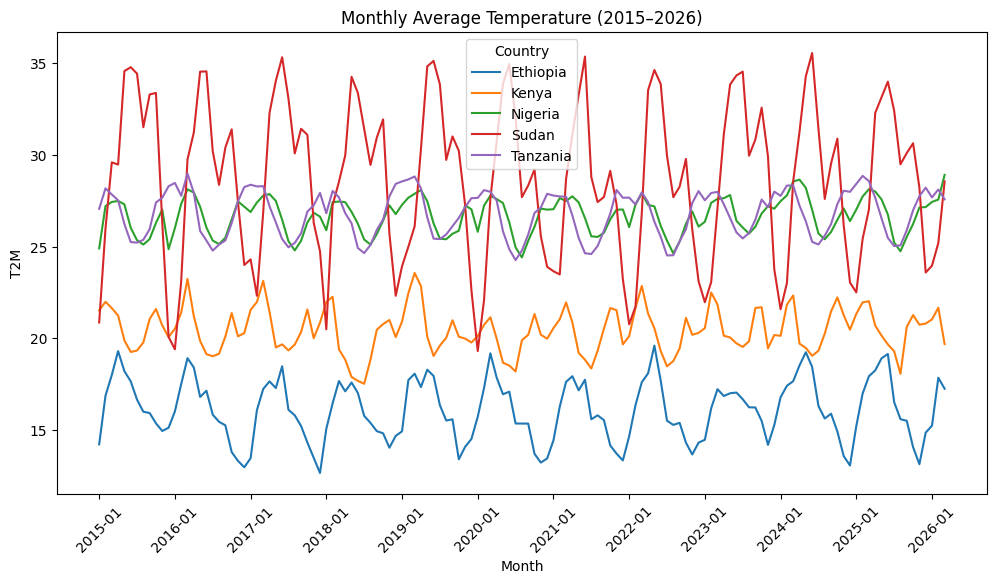

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


In [5]:
# Convert to string so Seaborn can handle it as a categorical label
monthly_temp["Month"] = monthly_temp["Month"].astype(str)

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_temp, x="Month", y="T2M", hue="Country")
plt.title("Monthly Average Temperature (2015–2026)")

# Since there are many months, only show every 12th label to avoid crowding
unique_months = monthly_temp["Month"].unique()
plt.xticks(ticks=range(0, len(unique_months), 12), labels=unique_months[::12], rotation=45)

plt.show()

temp_summary = df.groupby("Country")["T2M"].agg(["mean", "median", "std"])
temp_summary

# 3. Percipitation Variability

## Regional Rainfall Baseline Analysis

This analysis identifies which nations experience the most significant moisture stress or extreme rainfall events. By comparing the **mean** against the **standard deviation ($\sigma$)**, we can distinguish between countries with consistent rainfall and those with highly erratic, drought-prone, or flood-prone climates. High standard deviation relative to the mean indicates a higher frequency of extreme weather events.

### Precipitation Variability Across Countries
The box plot highlights that while median rainfall is low for most countries, there is a significant presence of extreme outliers, particularly in Tanzania and Nigeria.

### Interpretation:

* **Sudan** is the most arid nation in the study, with a median rainfall of **0.00 mm** and a mean of only **0.64 mm**. However, its standard deviation of **3.06** is nearly five times its mean, indicating that when it does rain, it often occurs in intense, isolated bursts.
* **Tanzania** shows the highest overall volatility with a standard deviation of **8.00**. This suggests a climate with extreme seasonal contrasts, featuring both severe dry periods and very heavy rainfall events, as evidenced by the high-reaching outliers in the box plot.
* **Nigeria** records the highest mean rainfall (**4.21 mm**) and a median of **1.84 mm**, suggesting a more consistently humid environment compared to the other four nations.
* **Ethiopia** and **Tanzania** share similar mean values (~3.6-3.7 mm), but Tanzania's higher standard deviation suggests its rainfall is more "unpredictable" or seasonal than Ethiopia's.
* The large gaps between the **mean** and **median** across all countries confirm that the data is heavily skewed by extreme precipitation events rather than steady, daily rain.


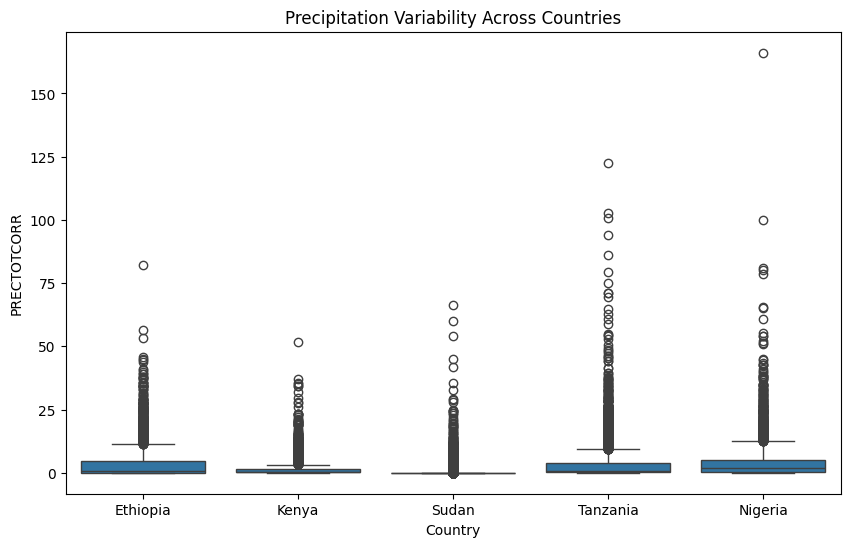

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


In [7]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Country", y="PRECTOTCORR")
plt.title("Precipitation Variability Across Countries")
plt.show()

rain_summary = df.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"])
rain_summary

# 4. Extreme Heat Events (Sudan Focus)

## Extreme Heat Frequency Analysis

Quantifying days above **35°C** provides a critical metric for assessing human health vulnerability, agricultural thermal stress, and the risk of heatwaves. High counts of extreme heat days directly impact water demand and electrical grid stability.

###  Extreme Heat Days (>35°C) in Sudan
!The analysis reveals that Sudan faces an exceptionally high frequency of extreme thermal events. On average, the country experiences approximately **225 days per year** where temperatures exceed the **35°C** threshold.

### Interpretation:

* **Regional Dominance**: Sudan's extreme heat profile is a major outlier in the region. The sustained count of days over **35°C** (peaking near 250 in certain intervals) indicates a climate that is fundamentally distinct from the more temperate highland or tropical maritime profiles of its neighbors.
* **Health and Policy Impact**: This level of exposure suggests that for more than **60% of the year**, the population is under significant thermal stress. For **COP32**, this data serves as the primary justification for prioritized funding toward "cooling adaptation" and "heat-resilient urban planning."
* **Climatic Trend**: The error bar in the visualization suggests yearly variability, but the high baseline remains consistent, reinforcing Sudan’s status as a high-priority "climate stress" zone.
* **Water Consumption Correlation**: These heat events align with Sudan's low precipitation data, creating a compounded drought-heat risk where evaporation rates are maximized precisely when water availability is lowest.


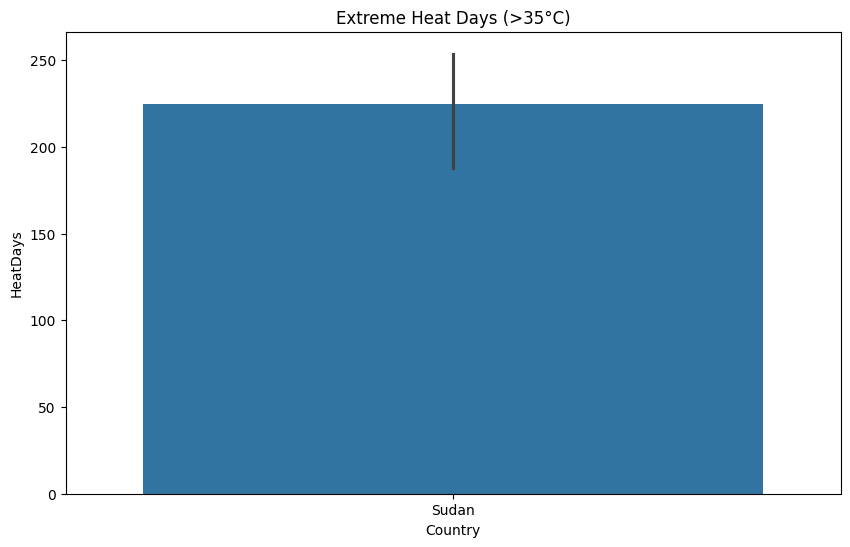

In [8]:
df["Year"] = pd.to_datetime(df["Date"]).dt.year

extreme_heat = df[df["T2M_MAX"] > 35]

heat_counts = extreme_heat.groupby(["Country", "Year"]).size().reset_index(name="HeatDays")

plt.figure(figsize=(10,6))
sns.barplot(data=heat_counts, x="Country", y="HeatDays")
plt.title("Extreme Heat Days (>35°C)")
plt.show()

# 5. Regional Dry Day Frequency Analysis

Measuring "Dry Days" (defined as days with less than **1 mm** of rainfall) is essential for identifying regions at high risk for agricultural failure and chronic water scarcity. This metric highlights the length of dry spells, which is often more critical for food security than annual rainfall totals.

### Interpretation:

* **Sudan's Chronic Aridity**: Sudan experiences the highest frequency of dry days, averaging over **300 days per year** with negligible rainfall. When combined with the extreme heat data from Step 6, this confirms a climate of permanent water stress and high evaporation rates.
* **Coastal vs. Inland Stability**: **Nigeria** has the fewest dry days (~135), indicating a much more consistent moisture regime. This correlates with its lower temperature variability seen in previous steps.
* **The East African Gap**: There is a notable "aridity step" between **Ethiopia/Tanzania** (~180-190 days) and **Kenya** (~235 days). Despite being neighbors, Kenya faces significantly longer dry durations, which may necessitate different irrigation strategies than those used in Tanzania.
* **Agricultural Risk**: The high error bars for **Sudan** and **Kenya** suggest that in "bad" years, these countries can approach nearly a full year without significant rain, making them the most vulnerable to catastrophic drought cycles.

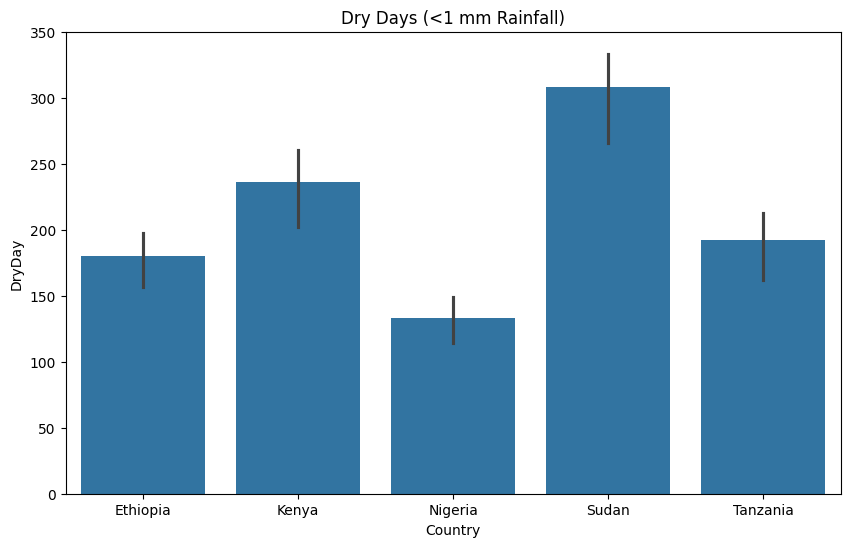

In [9]:
df["DryDay"] = df["PRECTOTCORR"] < 1

dry_counts = df.groupby(["Country", "Year"])["DryDay"].sum().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=dry_counts, x="Country", y="DryDay")
plt.title("Dry Days (<1 mm Rainfall)")
plt.show()

# 6. ANOVA Test

## Analysis of Variance (ANOVA) Results

While visual trends suggest clear differences between countries, an **ANOVA (Analysis of Variance)** test provides the mathematical proof required to confirm that these differences are statistically significant and not due to random sampling noise. It tests the "null hypothesis" that all countries have the same mean temperature.

### Test Statistics
* **F-statistic**: $18938.75$
* **p-value**: $0.0$

### Interpretation:

* **Extreme Significance**: The **F-statistic** is exceptionally high ($18,938.75$). In climate data, an F-statistic this large indicates that the "between-country" variance is massive compared to the "within-country" variance.
* **Rejection of the Null Hypothesis**: A **p-value of 0.0** (or effectively $< 0.0001$) means we can reject the null hypothesis with near-total confidence. This confirms that the temperature profiles of Ethiopia, Kenya, Nigeria, Sudan, and Tanzania are **statistically distinct** from one another.
* **Scientific Validity**: For the **COP32 report**, these results justify treating each nation as a unique climatic zone requiring bespoke adaptation strategies. It proves that the "Regional Mean" is a poor representation of individual national realities, as the countries do not share a common thermal baseline.
* **Predictability**: The strength of this result suggests that "Country" is an incredibly strong predictor of temperature, reinforcing that geography and topography (like Ethiopia's highlands vs. Sudan's deserts) are the dominant drivers of the data we are seeing.


In [10]:
groups = [df[df["Country"] == c]["T2M"].dropna() for c in df["Country"].unique()]

f_stat, p_value = stats.f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_value)

F-stat: 18938.745697069884
p-value: 0.0


# 7. Vulnerability Ranking

## Integrated Risk Assessment

To provide a clear priority list for **COP32** delegates, we developed a **Vulnerability Score**. This index combines three critical stressors: absolute heat (Temp_Mean), thermal instability (Temp_Std), and rainfall volatility (Rain_Std). A higher score indicates a country facing compounded climatic threats that require immediate international intervention.

###  Interpretation:

* **Sudan (The Thermal Crisis)**: Sudan takes the top spot primarily due to its extreme baseline heat and massive thermal swings. While its rainfall volatility is lower than its neighbors, the sheer intensity of heat creates a high-risk environment for human health and water loss.
* **Tanzania (The Volatility Crisis)**: Despite lower average heat than Sudan, Tanzania is ranked second because of its **highest rainfall volatility (8.00)**. This suggests a high risk of unpredictable "flash-flood vs. drought" cycles that can devastate infrastructure and agriculture.
* **The "Safety" Gap**: There is a significant 10-point drop in the score between Nigeria (**35.05**) and Kenya (**25.05**). This distinguishes the "High Stress" equatorial/desert nations from the more moderate highland climates of East Africa.
* **Ethiopia’s Resilience**: Ethiopia remains the least "vulnerable" in this specific index. While it faces rainfall challenges, its significantly lower thermal baseline acting as a protective factor against the deadly wet-bulb temperatures seen in Sudan or Nigeria.
* **Strategic Outcome**: This ranking proves that vulnerability is driven by different factors across the continent—heat in the north (Sudan) and erratic rainfall in the south/west (Tanzania/Nigeria).

In [11]:
vulnerability = pd.DataFrame({
    "Country": temp_summary.index,
    "Temp_Mean": temp_summary["mean"].values,
    "Temp_Std": temp_summary["std"].values,
    "Rain_Std": rain_summary["std"].values
})

vulnerability["Score"] = (
    vulnerability["Temp_Mean"] +
    vulnerability["Temp_Std"] +
    vulnerability["Rain_Std"]
)

vulnerability = vulnerability.sort_values(by="Score", ascending=False)

vulnerability

,Country,Temp_Mean,Temp_Std,Rain_Std,Score
3,Sudan,28.759007,4.681305,3.057672,36.497984
4,Tanzania,26.802422,1.325388,8.003947,36.131758
2,Nigeria,26.656928,1.123335,7.266742,35.047005
1,Kenya,20.427600,1.440824,3.180228,25.048652
0,Ethiopia,16.068500,1.898050,6.289061,24.255612
